# Erdos Institute Summer 2026 Project
## Sustainability of US cities

This project attempts to answer the following:

&#9989; **<font color=blue>QUESTION:** <font color=blue>Where should someone live for the next 20 years? 

We will try to determine which U.S. counties/cities are the most environmentally, economically, and socially sustainable using sustainability metrics from the [United Nations Sustainable Development Goals](https://sdgs.un.org/goals). 

---
This notebook will show some exploratory data analysis along the theme of social and economic sustainability, as follows:

- Obtaining data
- Data cleaning
- Exploratory Data Analysis
- Modeling
- Pipelines
- Basic model evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

#### 1. Load the data

##### a.

First, load and preview the data from the appropriate folder.

In [7]:
credit_scores = pd.read_csv("../data/social_economic/avg_credit_score_2020_cty.csv", usecols=[0,1,4])

In [8]:
credit_scores.sample(5)

,par_state,par_county,shrunk_xkid_vscore2020
25026,27,55,691.85
4825,6,95,675.90
50833,48,449,663.05
10229,13,245,721.10
23246,26,51,634.00


##### b.

Create a new column of the `DataFrame` called `y` where `y=1` if `Class=Ürgüp Sivrisi` and `y=0` if `Class=Çerçevelik`.

##### Sample Solution

In [15]:
credit_scores['y'] = 0

credit_scores.loc[credit_scores.shrunk_xkid_vscore2020>=670, 'y']=1

#### 2. Learn about the data

##### a.

These data represent...

#### 3. Train test split

##### a.

Look at how the data is split between the two classes. Does this appear to be imbalanced data? <i>Recall that we say data is imbalanced if one of the classes has a very small presence in the data set.

##### Sample Solution

In [16]:
credit_scores.y.value_counts(normalize=True)

y
0    0.511181
1    0.488819
Name: proportion, dtype: float64

This data set seems pretty well balanced.??

##### b.

Make a train test split, set aside $20\%$ of the data as the test set.  You should stratify with respect to the target to ensure class balance.

##### Sample Solution

In [17]:
from sklearn.model_selection import train_test_split

The next few cells give you an example to see how `train_test_split` works.

In [14]:
# You can look at the docstring for train_test_split as follows:
# ?train_test_split

In [26]:
cs_train, cs_test = train_test_split(credit_scores,
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.2,
                                              stratify=credit_scores.y)

In [27]:
cs_tt, cs_val = train_test_split(cs_train,
                                              shuffle=True,
                                              random_state=123,
                                              test_size=.2,
                                              stratify=cs_train.y)

To compare different candidate models we will use a single *validation set*.  Further split the training set into training and validation sets.

In [23]:
# What do cs_train and cs_test look like?  What shape are they?  What is the proportion of ones in the final column?

print(f'The shape of cs_train is {cs_train.shape}.  It\'s proportion of ones is {cs_train.iloc[:,-1].sum()/(cs_train.shape[0])}')
print(f'The shape of cs_test is {cs_test.shape}.  It\'s proportion of ones is {cs_test.iloc[:,-1].sum()/(cs_test.shape[0])}')

The shape of cs_train is (47152, 4).  It's proportion of ones is 0.4888233797081778
The shape of cs_test is (11788, 4).  It's proportion of ones is 0.4888021717000339


#### 4. Exploratory data analysis (EDA)

Before building any models you will do some EDA.

##### a. 

One way to try and identify key features for classification algorithms is to plot histograms of the feature values for each of the classes.

Below is an example of such a histogram for the `Area` column made using `plt.hist`.

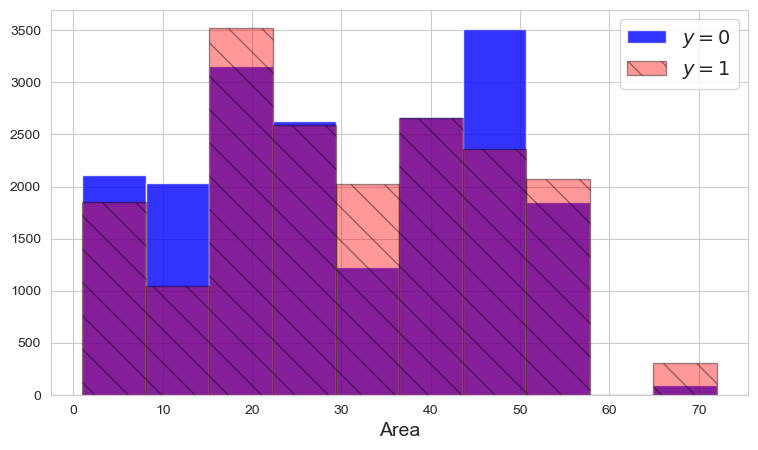

In [33]:
plt.figure(figsize=(9,5))


plt.hist(cs_tt.loc[cs_tt.y==0].par_state,
            color='blue',
            alpha=.8,
            label="$y=0$")

plt.hist(cs_tt.loc[cs_tt.y==1].par_state,
            color='red',
            alpha=.4,
            hatch = '\\',
            edgecolor='black',
            label="$y=1$")

plt.xlabel("Area", fontsize=14)
plt.legend(fontsize=14)

plt.show()